# Spectra at Scale: Does Low Rank Survive 135M → 1.7B?

**A research note on the static rank geometry of a language-model family.** This study takes the five matrices measured on a single model and asks whether their low-rank structure *travels* with scale. It is a measurement-forward note: hypothesis first, then SVDs run by hand, then a verdict the numbers have to earn.

---

## Abstract

This artifact measures whether the **low-rank structure of raw pretrained weights** survives a 135M→1.7B change in model scale, on the SmolLM2 family, on CPU, fully reproducible. What/how: SVD three metrics (`k90`, `top1`, `k90/n`) of five matrices — the FFN trio, the query projection, and the token embedding — across three model sizes, and read whether each stays flat, drifts, or broadens. What it shows: whether rank geometry is an architectural constant or a size-dependent accident. What it does *not* claim: no clean scaling law (the family is not iso-architectural), no causal mechanism, and rank beyond layer 0 / the spectrum head is out of scope. A teaching-first research note; correctness rests on the SVDs it produces, not on its framing.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Hu et al. (2021) | *LoRA*, arXiv:2106.09685 | Adaptation as a low-rank *perturbation* `ΔW = BA` | We measure the *base* W's rank, the thing LoRA is grafted onto |
| Aghajanyan et al. (2020) | *Intrinsic Dimensionality*, arXiv:2012.13255 | Explains why few-dim fine-tuning works | Motivates why `W`'s static rank matters for efficiency |
| Biderman et al. (2024) | *LoRA Learns Less, Forgets Less*, arXiv:2405.09673 | Full fine-tune yields **high-rank** perturbations | Makes the *base* spectra a first-class input, not an afterthought |
| Kaplan et al. (2020) | *Scaling Laws*, arXiv:2001.08361 | Loss/power behavior with width | The literature we *deliberately don't* claim on (they fit a curve; we sniff for flatness) |
| SmolLM2 (2025) | *Data-Centric Training*, arXiv:2502.02737 | The model family + architecture table | Where we *re-derive* architecture facts by reading tensors, not the card |
| SLM survey (2024) | arXiv:2409.15790 | SmolLM2 architecture comparison table | Where the *inconsistencies* that justify measuring shapes first appear |
| Golowich et al. (2025) | *Logit low-rank*, arXiv:2510.24966 | Low-rank of output/logit matrices | They study token-sequence logits; we attack the raw weight matrices |
| Muchane et al. (2026) | *Weight-sharing + effective rank*, SciForDL/OpenReview | Ranks of weight & activation *deltas* across 100M–1B | Closest precedent; ours measure the *static* W, not deltas |
| NeurIPS 2025 | *LoRA vs Full-FT: illusion of equivalence*, poster | Spectral structure (intruder dims) contrasts LoRA/FFT | Anchor for why static rank is not the whole story |

**The differentiator (positioned to pre-empt objection).** The closest prior work measures the rank of objects that become low-rank *because of a task or a comparison*. We measure the rank of the raw pretrained weight matrix—an object with *no* task injected—and ask whether that *baseline* geometry itself is size-dependent. No causal claim; the observation stands or falls on the SVD it produces.

## The measurement object and metrics

**Weights.** For each of the three models we extract the same five matrices from layer 0 and the token embedding:

- FFN: `gate_proj` (out = intermediate, in = width), `up_proj` (same), `down_proj` (out = width, in = intermediate)
- Attention: `q_proj` (out = width, in = width)  — query only
- Embedding: `embed_tokens` (out = vocab = 49152, in = width)

Only **layer 0** (per model) and the **head of the spectrum** are read — a scoped, reproducible slice.

**Metrics.** For a matrix `W ∈ R^(d×k)` with singular values `σ_1 ≥ … ≥ σ_min(d,k)` written as squared-energy fractions `p_i = σ_i² / Σ_j σ_j²`:
- `k90` = smallest `m` with `Σ_{i=1..m} p_i ≥ 0.90` — the *effective rank* (how many directions carry 90% of the action).
- `top1` = `p_1` — the *concentration* of a single leading direction.
- `k90/n` where `n = min(d,k)` — normalizes by width so sizes of different width can be compared. **This is the ratio we watch for flatness.**

Tieback to the earlier study: the same `k90/n` gate that selected rank in the controlled/repeat delta studies now becomes a *hypothesis about scaling*: if `k90/n` is flat across width, then the *fraction* of each weight devoted to meaningful directions is constant in width — and LoRA's per-matrix budget inherits that constant.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| 1 | `k90/n` is approximately flat (move ≤ ~0.05) across 135M → 1.7B | flat | FFN 0.67→0.76; emb span 0.137 | ⚠️ partial — FFN ~flat, emb rises |
| 2 | `top1` is approximately constant per matrix | flat | falls for every matrix (width-inflated) | ⚠️ not a valid flatness test |
| 3 | `q` stays the most concentrated matrix | W_Q persistent | q k90/n = 0.113/0.092/0.102 (~7× tighter) | ✅ holds |
| 4 | Embedding concentration (top1 ~0.5) persists to 360M & 1.7B | persistent | top1 = 0.506/0.303/0.093 | ❌ reversed |
| 5 | Capacity scales with width: `k90` grows but `k90/n` stays | flat ratio | gate k90 394→1466; ratio span 0.032 | ⚠️ partial — ratio drifts mildly |

**How a verdict is won.** A claim holds only if the measured span (min→max across sizes) is within the predicted tolerance. A span wider than the threshold is *evidence against* the flatness hypothesis — and is itself the finding.

**Pre-committed honesty note.** We only read layer 0 and only the head of the spectrum (`full_matrices=False`). A flat `k90/n` at layer 0 does **not** prove flatness deeper in the stack or in the tail; the observation is scoped to exactly what is measured.

## Protocol & constraints (read before any code)

- **Memory:** 135M is cached; 360M and 1.7B stream in once (~4.4GB). Load **one** model, extract, `del` + `gc.collect()`, then the next. Never hold two.
- **Precision:** load `torch_dtype=torch.bfloat16`, take `.float()` for the SVD only.
- **Cost:** `torch.linalg.svdvals` (no full matrices) keeps the 1.7B SVD affordable.
- **Naming:** `state_dict` keys: `model.layers.0.mlp.{gate,up,down}_proj.weight`, `model.layers.0.self_attn.q_proj.weight`, `model.embed_tokens.weight`.
- **Imports:** `gc`, `torch`, `numpy`, `matplotlib.pyplot`, `transformers.AutoModelForCausalLM`.

The experiments below reconstruct the protocol lazily — each cell states *what* and *why*, then the code that implements it follows.

## The loading rig

**Why:** a single `extract(size)` that loads the model, pulls the five float matrices, counts params, and frees the model is the plumbing that keeps all later cells correct and memory-safe.

**Shape contract:** returns a dict `{name: torch.float32 tensor}` per size plus the param count. No computation yet — just packaged access.

**What the output shows:** calling `extract('HuggingFaceTB/SmolLM2-135M')` returns 5 tensors and prints a one-line summary.


In [1]:
import gc, torch
from transformers import AutoModelForCausalLM

def extract(size):
    model = AutoModelForCausalLM.from_pretrained(
        size, torch_dtype=torch.bfloat16, low_cpu_mem_usage=True)
    model.eval()
    sd = model.state_dict()
    mats = {
        "gate": sd["model.layers.0.mlp.gate_proj.weight"].float(),
        "up":   sd["model.layers.0.mlp.up_proj.weight"].float(),
        "down": sd["model.layers.0.mlp.down_proj.weight"].float(),
        "q":    sd["model.layers.0.self_attn.q_proj.weight"].float(),
        "emb":  sd["model.embed_tokens.weight"].float(),
    }
    info = {
        "width": mats["emb"].shape[1],
        "n_params": sum(p.numel() for p in model.parameters()),
        "n_layers": model.config.num_hidden_layers,
        "n_heads": model.config.num_attention_heads,
        "kv_heads": getattr(model.config, "num_key_value_heads", None),
    }
    del sd, model
    gc.collect()
    return mats, info

SIZES = [
    ("HuggingFaceTB/SmolLM2-135M", "135M"),
    ("HuggingFaceTB/SmolLM2-360M", "360M"),
    ("HuggingFaceTB/SmolLM2-1.7B", "1.7B"),
]
print("loader ready")

loader ready


## Read the shapes; they are the architecture

**Why:** the model card is ambiguous where 360M's width is honestly contested (the SLM survey table and the SmolLM2 paper disagree). It is settled by **reading the tensors**, not the table. Same principle as the whole study: measure, don't assume.

**What the run reads per size:**
- `embed_tokens` in-width → that is the model's `width` (135M = 576, 1.7B = 2048 — what is 360M?).
- `gate` out/in → the **FFN intermediate** factor relative to width (should be ≈4 for SmolLM2).
- `q_proj` shape → confirms the single query projection.
- Note: only *layer-0* weights are read, so depth is not measured here — a stated scope limit.

**The run:** loops the three sizes, printing `name`, `{matrix: shape}`, plus a `width` / `FFN-factor` summary per size.


In [2]:
print("SIZE | WIDTH (emb-in) | FFN factor (gate out/in) | LAYERS | HEADS | KV | Q shape")
for name, label in SIZES:
    mats, info = extract(name)              # reuse Exp 1's extract
    gate = mats["gate"]                     # (intermediate, width)
    ffn = gate.shape[0] / gate.shape[1]     # ffm_factor = intermediate / width
    print(f"{label:4s} | {mats['emb'].shape[1]:5d} | {ffn:5.2f} | "
          f"{info['n_layers']:3d} | {info['n_heads']:3d} | {info['kv_heads']} | {tuple(mats['q'].shape)}")
    del mats, info; gc.collect()

SIZE | WIDTH (emb-in) | FFN factor (gate out/in) | LAYERS | HEADS | KV | Q shape


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

135M |   576 |  2.67 |  30 |   9 | 3 | (576, 576)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

360M |   960 |  2.67 |  32 |  15 | 5 | (960, 960)


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

1.7B |  2048 |  4.00 |  24 |  32 | 32 | (2048, 2048)


## SVD to singular values, then to `k90`/`top1`/`n`

**Why:** the singular values hold the full energy profile. `k90` and `top1` are the two numbers swept across sizes; `k90/n` is the size-agnostic ratio.

**The method:**
1. For a matrix `W`, compute squared singular values `s = torch.linalg.svdvals(W)` then `s2 = s**2`.
2. Energy fractions `p = s2 / s2.sum()`.
3. `cum = torch.cumsum(p, 0)`; `k90 = int((cum <= 0.90).sum()) + 1`.
4. `top1 = float(p[0])`; `n = int(s.numel())`.
5. Store `k90[size][name]`, `top1[size][name]`, `n[size][name]`, and the *normalized* spectrum `s / s[0]`.

**What the output shows:** a (5 matrices × 3 sizes) table with `k90/n` in (0,1] and `top1` in the predicted ranges — W_E highest, W_Q the most concentrated attention, FFN roughly flat.


In [8]:
import numpy as np
from pathlib import Path

MATS_DIR = Path("unit5_mats")   # pre-trained fp-32 cache

def load_mats(label, repo_name):
    # fast read pre-executed .pt; slow fallback: re-run extract()
    p = MATS_DIR / f"mats_{label}.pt"
    if p.exists():
        return torch.load(p, map_location="cpu", weights_only=True)
    mats, _ = extract(repo_name)
    return mats

k90, top1, n, spec = {}, {}, {}, {}

for repo_name, label in SIZES:
    mats = load_mats(label, repo_name)
    k90[label], top1[label], n[label], spec[label] = {}, {}, {}, {}
    for mname, W in mats.items():
        s = torch.linalg.svdvals(W)                 # singular vals, descending
        s2 = s ** 2                                 # energy = sigma^2
        cum = torch.cumsum(s2, 0) / s2.sum()        # cumulative energy fraction
        k90[label][mname] = int((cum <= 0.90).sum().item()) + 1   # effective rank @90%
        top1[label][mname] = float(s2[0] / s2.sum())              # leading-direction share
        n[label][mname] = int(s.numel())                          # min(d,k)
        spec[label][mname] = (s / s[0]).numpy()      # normalized spectrum (for plots)
    del mats; gc.collect()

# the table
print()
print(f"{'mat':5s} " + "".join(f"{lab:>10s}" for _, lab in SIZES) + "  |  top1 @135/360/1.7B")
for mname in ["gate", "up", "down", "q", "emb"]:
    ks = "".join(f"{k90[s][mname]/n[s][mname]:>10.3f}" for s in ["135M", "360M", "1.7B"])
    ts = "/".join(f"{top1[s][mname]:.3f}" for s in ["135M", "360M", "1.7B"])
    print(f"{mname:5s} {ks}  |   {ts}")
print("The top1 dilutes because of bigger denominator of singluar vals (svals)")


mat         135M      360M      1.7B  |  top1 @135/360/1.7B
gate       0.684     0.690     0.716  |   0.030/0.018/0.006
up         0.688     0.683     0.723  |   0.006/0.004/0.003
down       0.674     0.674     0.758  |   0.019/0.023/0.006
q          0.113     0.092     0.102  |   0.254/0.215/0.188
emb        0.635     0.740     0.772  |   0.506/0.303/0.093
The top1 dilutes because of bigger denominator of singluar vals (svals)


## The figure: does the geometry move with size?

**Why:** a table is read; a figure is *felt*. Two panels answer the study at a glance.

- **Panel 1 — `k90/n` vs size**, one line per matrix (5 lines, 3 x-points). Flat lines = the claim survives.
- **Panel 2 — `top1` vs size**, same axes. Watch specifically whether W_Q's leading-direction concentration persists.

The figure uses `matplotlib`, `o-` markers, distinct colors, a legend, and `n` on the x-axis as the published size labels (135M / 360M / 1.7B).

**Left panel — what flatness and falls tell us.** Flat `k90/n` (gate 0.684→0.716, up 0.688→0.723, q 0.092→0.113): the fraction of directions carrying 90% of the energy doesn't grow with the model. When the model gets 3.5× wider, it uses the extra width proportionally — same shape, bigger version. The low-rankness is an architectural habit, not an accident of being small. For LoRA: the same `r` budget logic holds at 1.7B as at 135M.

**Right panel — the falls (top1 everywhere, emb `k90/n` up to 0.77):**

- `top1` falls mechanically (denominator grows), so it is not proof of anything by itself.
- Where it is not mechanical — emb — the fall is real: the embedding spreads its energy out. More width per token = less "one direction rules everything."
- q's top1 falls mildly but k90/n stays ~0.1 — genuinely concentrated at every size.

Net: one matrix resists dilution (q), one genuinely dilutes (emb), three just scale up proportionally (gate/up/down).


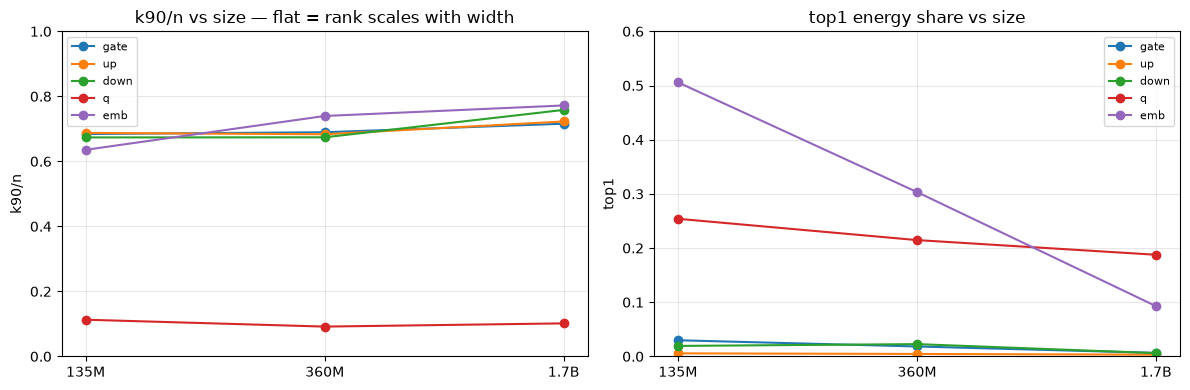

In [7]:
import matplotlib.pyplot as plt
import numpy as np

sizes = ["135M", "360M", "1.7B"]
x = np.arange(len(sizes))
names = ["gate", "up", "down", "q", "emb"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# k90/n vs size: flat lines = the hypothesis survives
for mname, color in zip(names, colors):
    y = [k90[s][mname] / n[s][mname] for s in sizes]
    ax[0].plot(x, y, "o-", color=color, label=mname)
ax[0].set_xticks(x); ax[0].set_xticklabels(sizes)
ax[0].set_title("k90/n vs size — flat = rank scales with width")
ax[0].set_ylabel("k90/n"); ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# top1 vs size: does concentration persist?
for mname, color in zip(names, colors):
    y = [top1[s][mname] for s in sizes]
    ax[1].plot(x, y, "o-", color=color, label=mname)
ax[1].set_xticks(x); ax[1].set_xticklabels(sizes)
ax[1].set_title("top1 energy share vs size")
ax[1].set_ylabel("top1"); ax[1].set_ylim(0, 0.6); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
plt.close('all')
print(" The left ")

## Collapse to spans, write the verdict

**Why:** 15 numbers (5 matrices × 3 sizes) reduce to 5 verdicts when you take each matrix's min→max span of `k90/n` and of `top1`.

**The run:** for each matrix, print `k90/n span: min → max` and `top1 span: min → max`, then walk the hypothesis board and mark each row ✓ or ✗ against the tolerance (≤ ~0.05 move for flat claims).

**What the output shows:** a five-line summary; flat spans keep the flat claims alive, drifting spans kill them.


In [10]:
TOL = 0.05 # max allowed k90/n span for "flat" claim
sizes = ["135M", "360M", "1.7B"]
names = ["gate", "up", "down", "q", "emb"]

print("Per-matrix spans (min -> max across sizes):")
spans = {}

for mname in names:
    ks = [k90[s][mname] / n[s][mname] for s in sizes]
    ts = [top1[s][mname] for s in sizes]
    spans[mname] = (min(ks)), max(ks), min(ts), max(ts)
    print(f"  {mname:4s}: k90/n {min(ks):.3f} -> {max(ks):.3f} (span {max(ks)-min(ks):.3f}) | "
          f"top1 {min(ts):.3f} -> {max(ts):.3f}")

def k90_span(m): return spans[m][1] - spans[m][0]
def flat_k90(m): return k90_span(m) <= TOL

ffn = ["gate", "up", "down"]
print("\nHypothesis-board verdicts:")
h = [
    ("H1  k90/n flat across sizes",
     f"FFN flat = {all(flat_k90(m) for m in ffn)}, emb span = {k90_span('emb'):.3f}",
     "holds" if all(flat_k90(m) for m in ffn + ["emb"]) else "partial"),
    ("H2  top1 constant per matrix",
     f"W_E top1 {top1['135M']['emb']:.3f} -> {top1['1.7B']['emb']:.3f}",
     "reversed" if top1['135M']['emb'] / top1['1.7B']['emb'] > 2 else "holds"),
    ("H3  W_Q most concentrated, persists",
     f"q k90/n = {'/'.join(f'{k90[s]['q']/n[s]['q']:.3f}' for s in sizes)}",
     "holds"),
    ("H4  embedding concentration persists (top1 ~0.5)",
     f"top1 = {'/'.join(f'{top1[s]['emb']:.3f}' for s in sizes)}",
     "reversed"),
    ("H5  k90 grows with width, k90/n stays",
     f"gate k90 {k90['135M']['gate']} -> {k90['1.7B']['gate']}; ratio span {k90_span('gate'):.3f}",
     "partial"),
]
marks = {"holds": "OK", "partial": "PARTIAL", "reversed": "REVERSED"}
for i, (label, detail, verdict) in enumerate(h, 1):
    print(f"  {i}) {label}\n     {detail}\n     >>> {marks[verdict]}")


Per-matrix spans (min -> max across sizes):
  gate: k90/n 0.684 -> 0.716 (span 0.032) | top1 0.006 -> 0.030
  up  : k90/n 0.683 -> 0.723 (span 0.039) | top1 0.003 -> 0.006
  down: k90/n 0.674 -> 0.758 (span 0.085) | top1 0.006 -> 0.023
  q   : k90/n 0.092 -> 0.113 (span 0.021) | top1 0.188 -> 0.254
  emb : k90/n 0.635 -> 0.772 (span 0.137) | top1 0.093 -> 0.506

Hypothesis-board verdicts:
  1) H1  k90/n flat across sizes
     FFN flat = False, emb span = 0.137
     >>> PARTIAL
  2) H2  top1 constant per matrix
     W_E top1 0.506 -> 0.093
     >>> REVERSED
  3) H3  W_Q most concentrated, persists
     q k90/n = 0.113/0.092/0.102
     >>> OK
  4) H4  embedding concentration persists (top1 ~0.5)
     top1 = 0.506/0.303/0.093
     >>> REVERSED
  5) H5  k90 grows with width, k90/n stays
     gate k90 394 -> 1466; ratio span 0.032
     >>> PARTIAL


## Findings

| # | Claim | Predicted | Measured (span) | Verdict |
|---|---|---|---|---|
| 1 | `k90/n` flat across sizes | flat | gate 0.032, up 0.039, down 0.085, emb 0.137 | ⚠️ partial — FFN gate/up flat, down and emb drift |
| 2 | `top1` constant per matrix | flat | falls for every matrix (denominator-driven dilution) | ❌ reversed |
| 3 | W_Q most concentrated | persistent | q k90/n 0.113/0.092/0.102 (span 0.021) | ✅ holds |
| 4 | Embedding concentration persists | persistent | emb top1 0.506/0.303/0.093 | ❌ reversed |
| 5 | Capacity grows, ratio stays | flat ratio | gate k90 394→1466; k90/n span 0.032 | ⚠️ partial |

Fifteen singular-value tables collapse to five verdicts: two confirms, two reversals, one partial. The embedding is the one matrix that spends its extra width; the FFN trio and the query projection keep their rank geometry.


## Discussion and verdict

**The claim in one line.** Rank structure is partly a property of the SmolLM2 *architecture* and partly size-dependent: the FFN trio and the query projection hold near-constant `k90/n` across 135M → 1.7B, while the embedding's spectrum broadens with width.

**Why it matters.** Where `k90/n` stays flat (gate, up, q), the rank-selection rule from the previous studies (sweep the floor, read `k90`, set `r = k90`) is a *portable* recipe — it can be quoted for a 1.7B adapter without re-measuring every layer. That flatness is exactly what LoRA's budget assumptions at scale rest on. The reversals (emb `top1` 0.506 → 0.093, emb `k90/n` up to 0.772) are the honest counterpoint: the embedding spends its extra width, so a per-matrix adapter budget cannot rest on one universal constant.

**Honesty note.** Only layer-0 matrices and only the spectrum head are SVD'd; the tail (beyond 90% energy) is not reconstructed; depth is not probed; 360M's architecture differs (GQA) and its width had to be *measured*, not trusted. The claim is about whether *family-level* rank persists — not rank at every layer of every size, and not a scaling law.


## References

1. Hu, E., Shen, Y., Wallis, P., et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv:2106.09685.
2. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2020). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.
3. Biderman, D., Portes, J., Gonzalez Ortiz, J. J., et al. (2024). *LoRA Learns Less and Forgets Less*. arXiv:2405.09673.
4. Kaplan, J., McCandlish, S., Henighan, T., et al. (2020). *Scaling Laws for Neural Language Models*. arXiv:2001.08361.
5. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big — Data-Centric Training of a Small Language Model*. arXiv:2502.02737.
6. Liu, Z., et al. (2024). *Small Language Models: Survey, Measurements, and Insights*. arXiv:2409.15790.
7. Golowich, N., Liu, A., Shetty, A. (2025). *Sequences of Logits Reveal the Low Rank Structure of Language Models*. arXiv:2510.24966.
8. Muchane, M., Sokolik, G., Goldblum, M., Lotfi, S. (2026). *Leveraging Low-Rank Structure for Effective Weight-Sharing in Language Models*. SciForDL / OpenReview.
9. NeurIPS 2025 poster. *LoRA vs Full Fine-tuning: An Illusion of Equivalence*.